# Dataset description
## Minimum wage over the years and a hypothetical one with the inflation

**Source**: Banco de la República

**Minimum Wage**: [link](https://suameca.banrep.gov.co/descarga-multiple-de-datos/)

**Inflation**: [link](https://suameca.banrep.gov.co/estadisticas-economicas/tablasPreconstruidas)

**Share of earnings**: [Mesa de concertación para el salario mínimo 2026](https://www.dane.gov.co/index.php/estadisticas-por-tema/mercado-laboral/empleo-y-desempleo/geih-historicos)

# Code
## Imports

In [92]:
from types import LambdaType
import pandas as pd
import matplotlib.pyplot as plt
from highlight_text import fig_text

## Load data

In [93]:
path_wage = "./data/salario_minimo.csv"
path_cpi = "./data/Total_Nacional.csv"
path_rng = "./data/rango_salarios.csv"

df_wage = pd.read_csv(path_wage, encoding="utf-8", usecols=[0,1])
df_cpi = pd.read_csv(path_cpi, encoding="utf-8", usecols=[0, 2])
df_rng = pd.read_csv(path_rng, encoding="utf-8", usecols=[0,1,2])

## Clean data

In [94]:
df_cpi["Fecha"] = pd.to_datetime(df_cpi["Fecha"])

# only data for december, except 2026 that gets the data from may since there is not data yet for december
cpi_f = df_cpi[
    (df_cpi["Fecha"].dt.year > 1999) &
    (((df_cpi["Fecha"].dt.year == 2026) & (df_cpi["Fecha"].dt.month == 5)) |
    ((df_cpi["Fecha"].dt.year != 2026) & (df_cpi["Fecha"].dt.month == 12)))
].rename(columns={"Variación anual (%)": "Inflacion"})

cpi_f["Fecha"] = cpi_f["Fecha"].dt.year

df = pd.merge(cpi_f, df_wage, how="inner").sort_values("Fecha", ascending=True)

df["Salario_Ajustado"] = df["Salario"].iloc[0].astype(float)

for i in range(1, len(df)):
    df.loc[df.index[i], "Salario_Ajustado"] = (
        df.loc[df.index[i-1], "Salario_Ajustado"] * 
        (1 + df.loc[df.index[i-1], "Inflacion"] / 100)
    )

df["Salario_Ajustado"] = round(df["Salario_Ajustado"], 0)

## Plot
### 1st chart

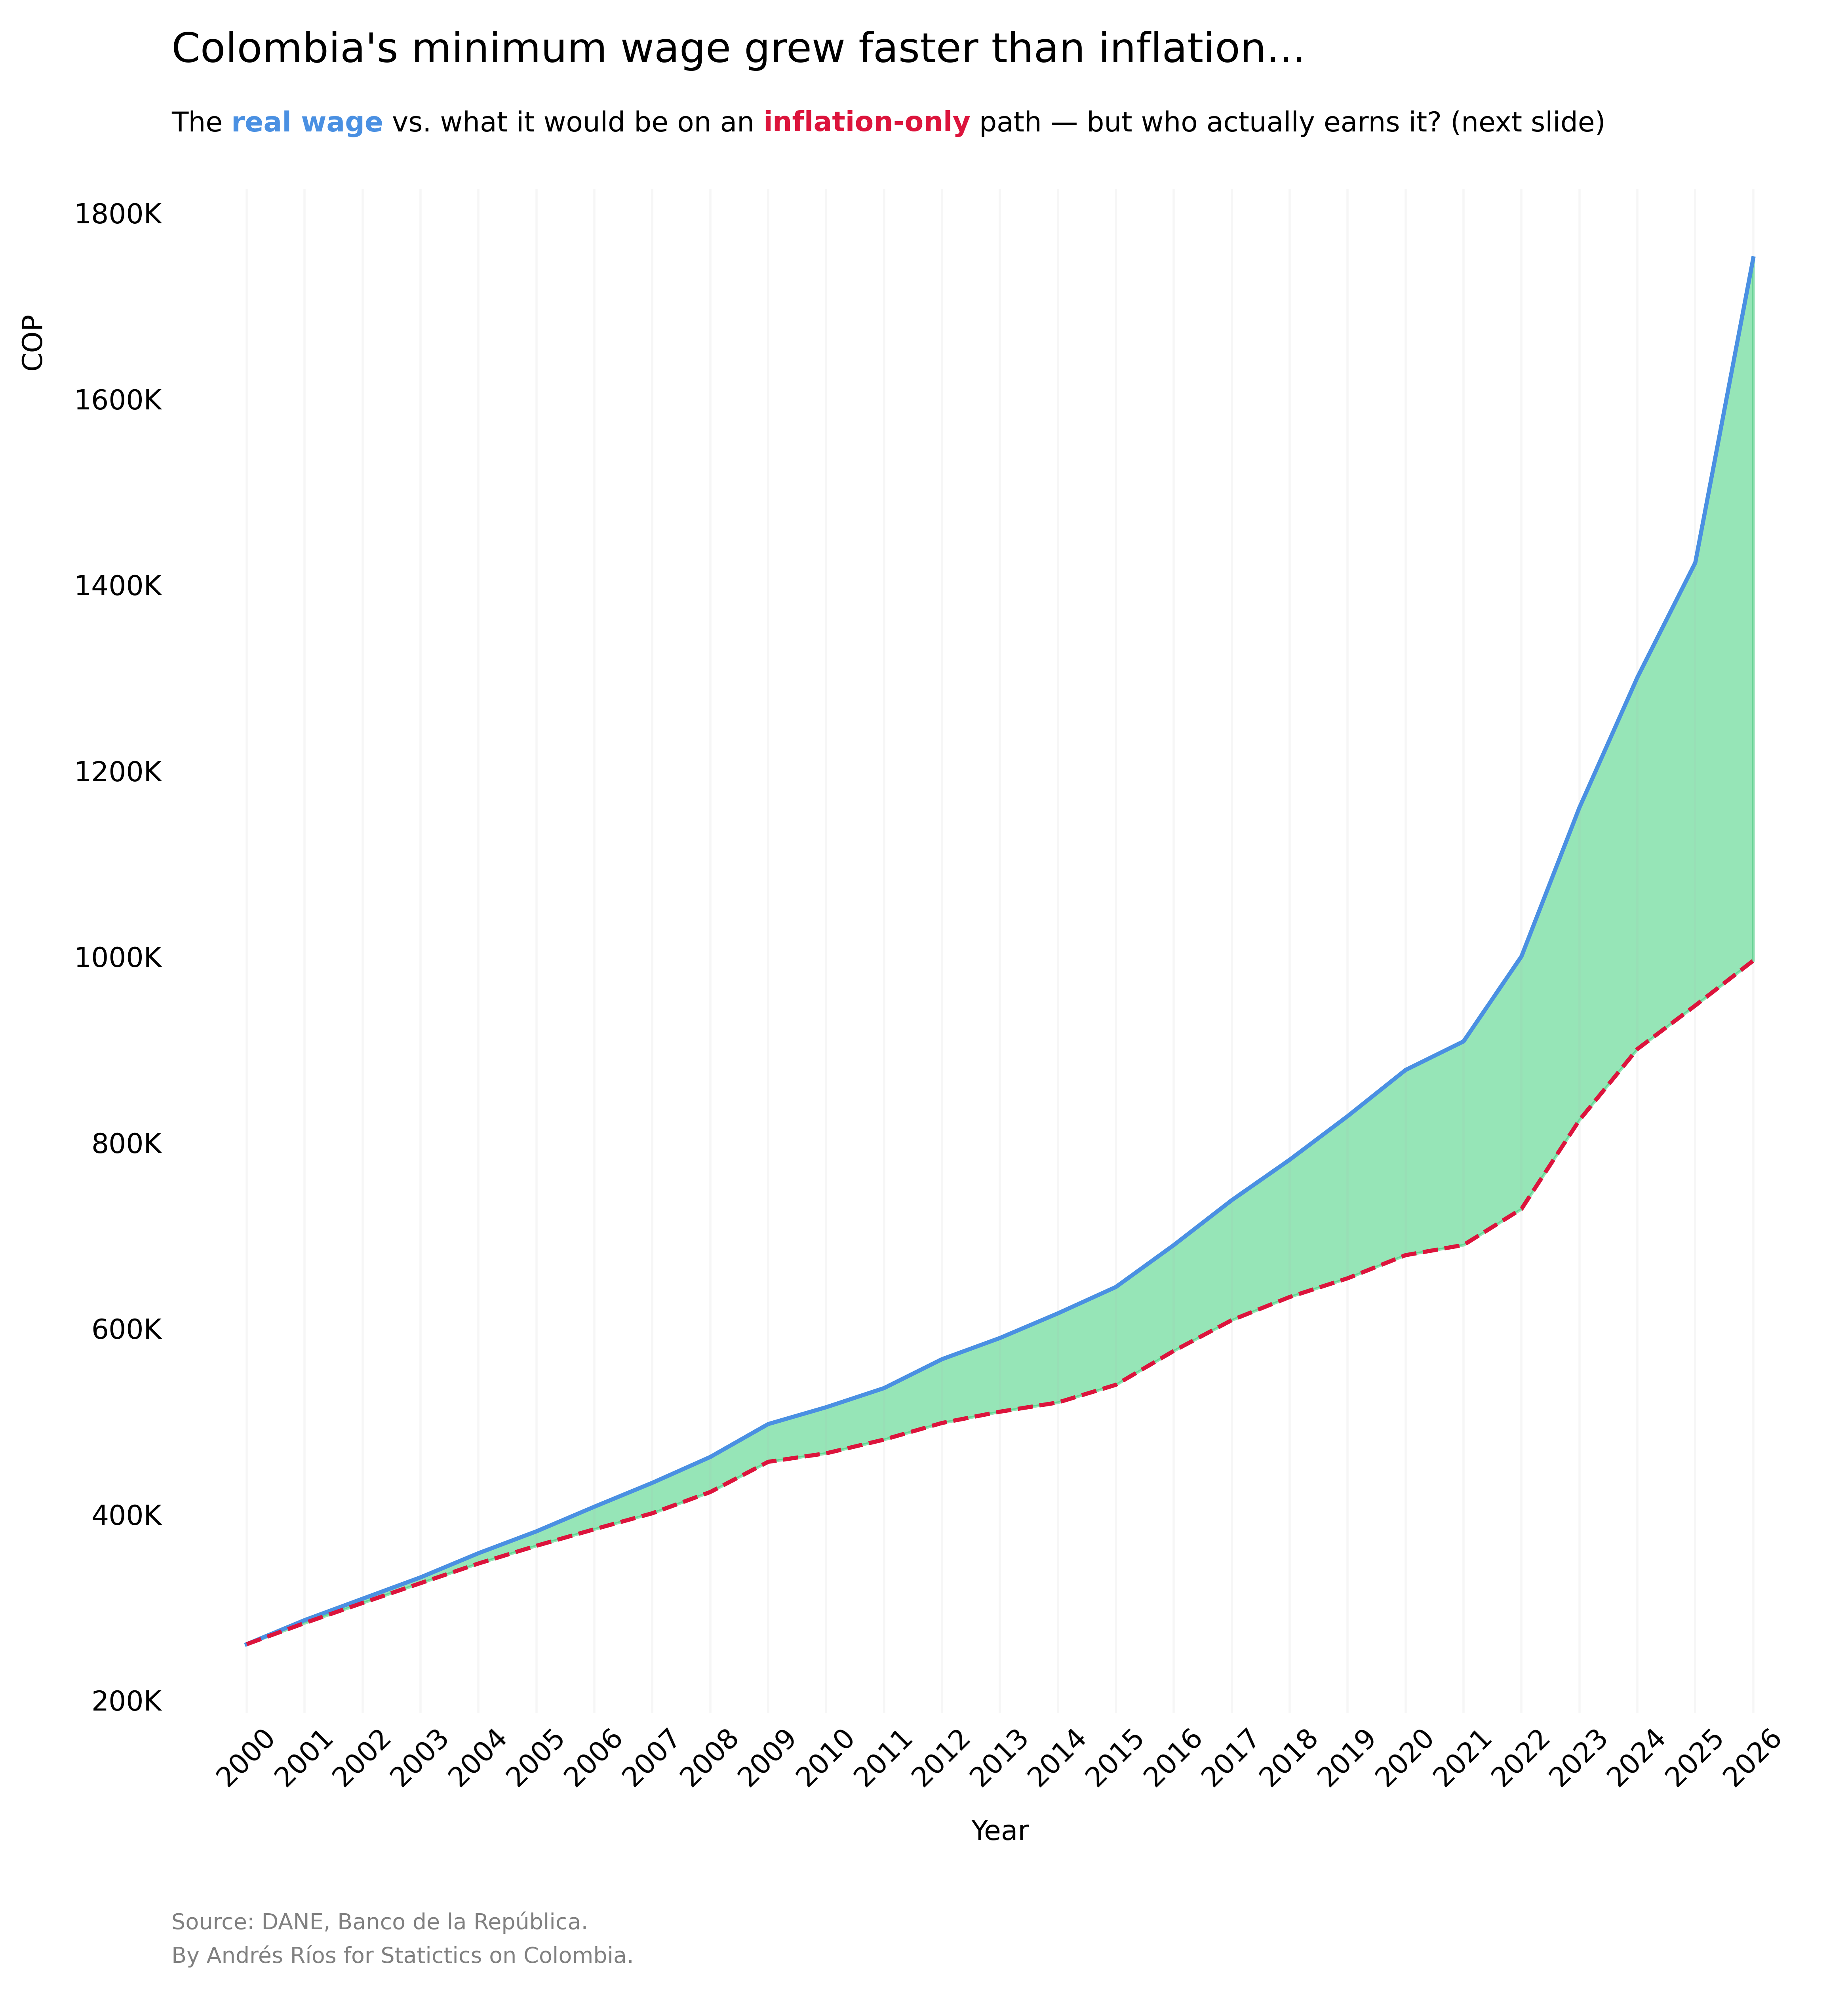

In [145]:
xaxis = df["Fecha"]
blue = "#4a90e2"
red = "#DC143C"
green = "#2ecc71"

plt.figure(figsize=(10.8, 10), dpi=500)

plt.plot(xaxis, df["Salario"], color=blue)
plt.plot(xaxis, df["Salario_Ajustado"], color=red, linestyle="--")

plt.xticks(xaxis, rotation=45)

plt.grid(axis="x", alpha=0.1)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.ylabel("COP", labelpad=10, fontsize=10, y=0.9)
plt.xlabel("Year", labelpad=10, fontsize=10)

plt.fill_between(xaxis, df["Salario"], df["Salario_Ajustado"], color=green, alpha=0.5)

fig_text(
    0.125, 0.96,
    s="Colombia's minimum wage grew faster than inflation...",
    fontsize=15
)

fig_text(
    0.125, 0.92,
    s="The <real wage> vs. what it would be on an <inflation-only> path — but who actually earns it? (next slide)",
    highlight_textprops=[
        {"color": blue, "weight": "bold"},
        {"color": red, "weight": "bold"}
    ],
    fontsize=10
)

fig_text(
    0.125, 0.01, 
    "Source: DANE, Banco de la República.\n"
    "By Andrés Ríos for Statictics on Colombia.", 
    fontsize=8, color="gray",
)

plt.show()

### 2nd Chart

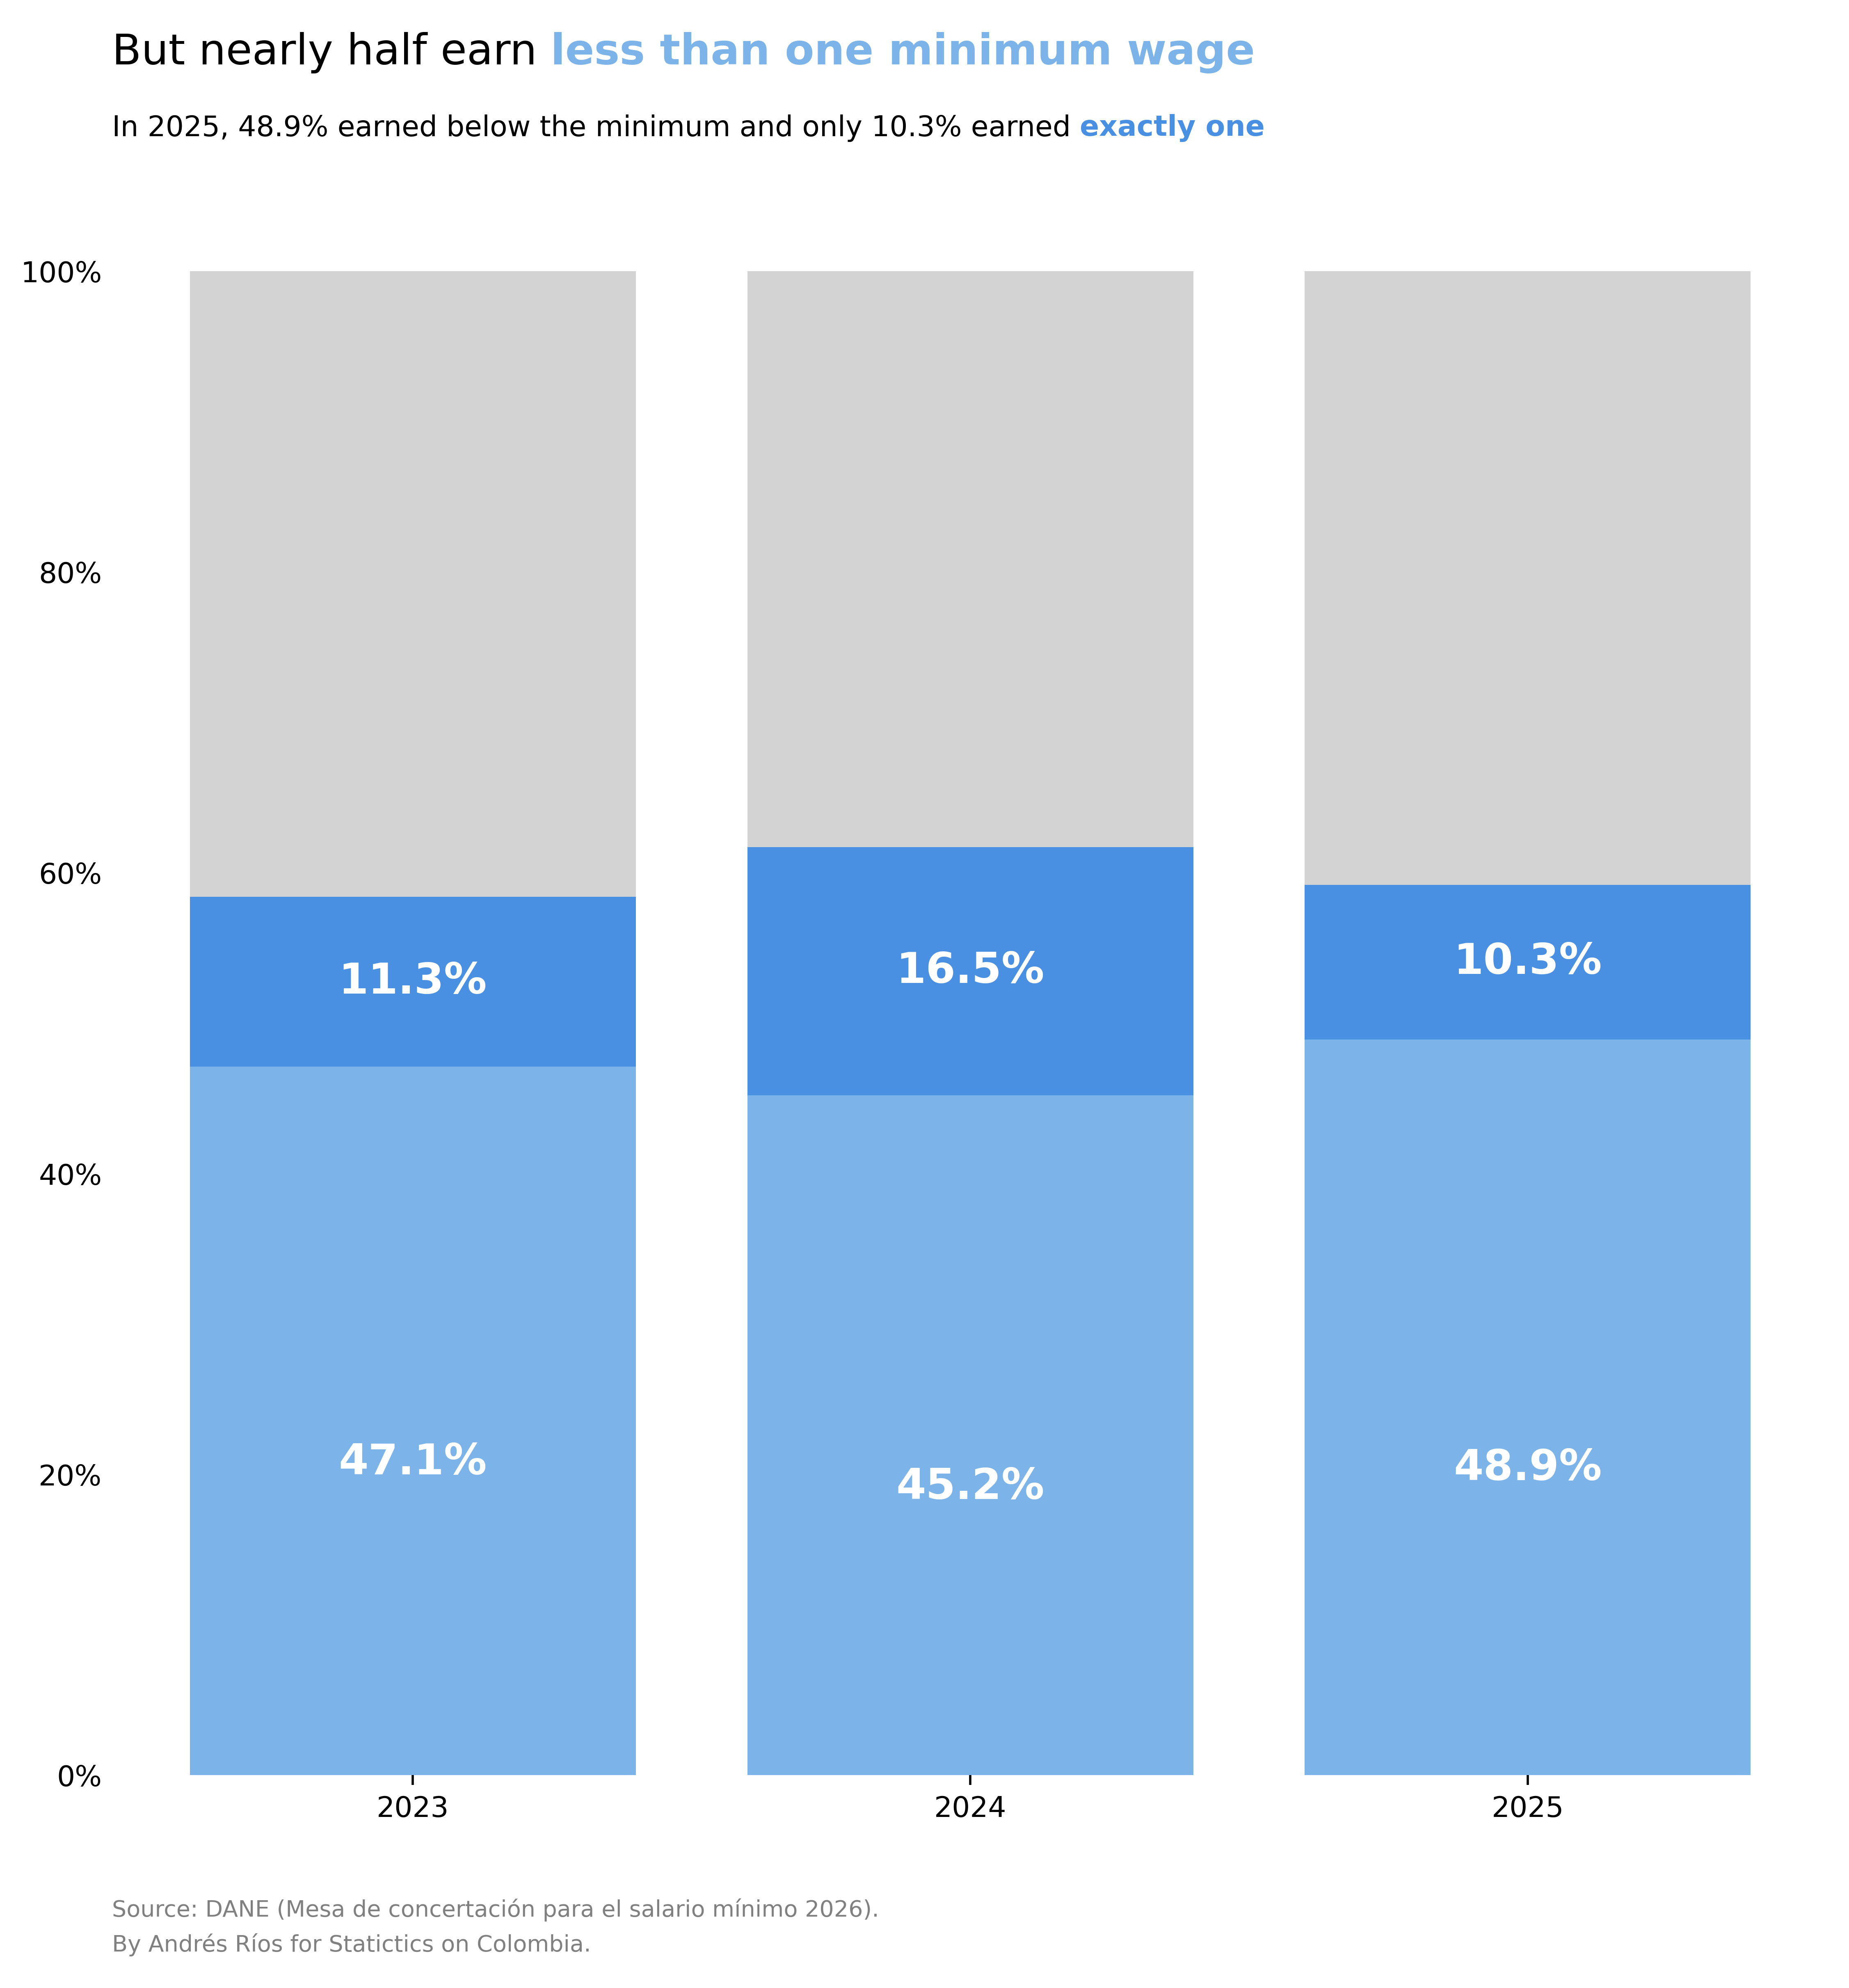

In [146]:
l1smmlv = df_rng["Menos de 1 smmlv"]
e1smmlv = df_rng["1 smmlv"]
tmp = list(zip(l1smmlv, e1smmlv))
others = [100 - p1 - p2 for p1, p2 in tmp]

xaxis = df_rng["Fecha"]
under = "#7CB3E8"
blue = "#4a90e2"
gray = "#D3D3D3"

plt.figure(figsize=(10.8, 10), dpi=500)

plt.bar(xaxis, l1smmlv, color=under)
plt.bar(xaxis, e1smmlv, bottom=l1smmlv, color=blue)
plt.bar(xaxis, others, bottom=[p1 + p2 for p1, p2 in tmp], color=gray)

for cat, w, pct in zip(xaxis, others, l1smmlv):
    plt.text(cat, w / 2, f"{pct:.1f}%", ha="center", va="center",
             color="white", fontweight="bold", fontsize=15)

bottom_e1 = l1smmlv
for cat, w, pct, b in zip(xaxis, e1smmlv, e1smmlv, bottom_e1):
    plt.text(cat, b + w / 2, f"{pct:.1f}%", ha="center", va="center",
             color="white", fontweight="bold", fontsize=15)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.xticks(xaxis)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

plt.tick_params(axis="y", length=0)

fig_text(
    0.125, 0.96,
    s="But nearly half earn <less than one minimum wage>",
    highlight_textprops=[{"color": under, "weight": "bold"}],
    fontsize=15
)

fig_text(
    0.125, 0.92,
    s="In 2025, 48.9% earned below the minimum and only 10.3% earned <exactly one>",
    highlight_textprops=[{"color": blue, "weight": "bold"}],
    fontsize=10
)

fig_text(
    0.125, 0.05, 
    "Source: DANE (Mesa de concertación para el salario mínimo 2026).\n"
    "By Andrés Ríos for Statictics on Colombia.", 
    fontsize=8, color="gray",
)

plt.show()